# Render atomic structures

Mdapy can use the Tachyon rendering algorithm developed by John Stone (http://www.photonlimited.com/~johns/tachyon/) to visualize atomic structures, with support for OVITO-compatible camera settings. This feature was introduced in mdapy 1.0.4 and may undergo API changes in future versions.

A key advantage is that it supports both CPU and GPU parallelization, providing excellent computational performance (**an order of magnitude faster**), especially for large-scale molecular dynamics rendering tasks.

In [1]:
import mdapy as mp
import numpy as np
import polars as pl
from time import time
from mdapy.render import TachyonRender, CameraParams, load_image
mp.__version__

'1.0.5a2'

In [2]:
import ovito
from ovito.vis import Viewport, TachyonRenderer
ovito.version

(3, 14, 1)

### Build a model with 32000 atoms

In [3]:
model = mp.build_hea(
        ["Cr", "Co", "Ni", "Fe", "Mn"],
        [0.2] * 5,
        "fcc",
        3.6,
        nx=20,
        ny=20,
        nz=20,
        random_seed=1,
    )
model.write_xyz('model.xyz')
model.N

32000

### Camera and rendering parameters

In [4]:
cam_pos = (-109.762, -70.4962, 94.5735)
cam_dir = (0.759042, 0.558131, -0.335178)
cam_up = (0.270034, 0.198559, 0.942155)
cam_fov = np.radians(35.0)
aa_samples = 20
ao_samples = 20
direct_light_intensity = 1.2
ao_brightness = 1.2
width, height = 3000, 3000 # we use high resolution here to test performance
background = (1, 1, 1)

Ovito setting

In [5]:
vp = Viewport()
vp.type = Viewport.Type.Perspective
vp.camera_pos = cam_pos
vp.camera_dir = cam_dir
vp.camera_up = cam_up
vp.fov = cam_fov

In [6]:
tachyon = TachyonRenderer(direct_light_intensity=direct_light_intensity, 
                          antialiasing_samples=aa_samples, 
                          ambient_occlusion_samples=ao_samples, 
                          ambient_occlusion_brightness=ao_brightness)

In [7]:
pipline = ovito.io.import_file('model.xyz')
pipline.add_to_scene()

In [8]:
time_list = []
start = time()
vp.render_image(size=(width,height), filename="ovito.png", background=background, renderer=tachyon);
time_list.append(time()-start)

In [9]:
pipline.remove_from_scene()

Mdapy setting

In [10]:
cam = CameraParams(
    field_of_view=cam_fov,
    position=cam_pos,
    direction=cam_dir,
    up=cam_up
)

### CPU rendering

In [11]:
tachyon_mda_cpu = TachyonRender(aa_samples=aa_samples, backend='cpu',
                            ao_samples=ao_samples, 
                            direct_light_intensity=direct_light_intensity, 
                            ao_brightness=ao_brightness, 
                            background=background)

In [12]:
start = time()
tachyon_mda_cpu.render_system(model, width=width, 
                            height=height, camera=cam, 
                            box_color=(0, 0, 0), box_edge_radius=0.2, 
                            output_figure='mda_cpu.png')
time_list.append(time()-start)

### GPU rendering

In [13]:
tachyon_mda_gpu = TachyonRender(aa_samples=aa_samples, backend='gpu',
                            ao_samples=ao_samples, 
                            direct_light_intensity=direct_light_intensity, 
                            ao_brightness=ao_brightness, 
                            background=background)

In [14]:
start = time()
tachyon_mda_gpu.render_system(model, width=width, 
                            height=height, camera=cam, 
                            box_color=(0, 0, 0), box_edge_radius=0.2,
                           output_figure='mda_gpu.png')
time_list.append(time()-start)

### Save transparent background figure

In [15]:
tachyon_mda_gpu.render_system(model, width=width, 
                            height=height, camera=cam, 
                            box_color=(0, 0, 0), box_edge_radius=0.2,
                           output_figure='mda_gpu_transparent.png', transparent=True)

### Compare results

The rendering results are generally similar, while the mdapy cpu version is a little bit darker than others.

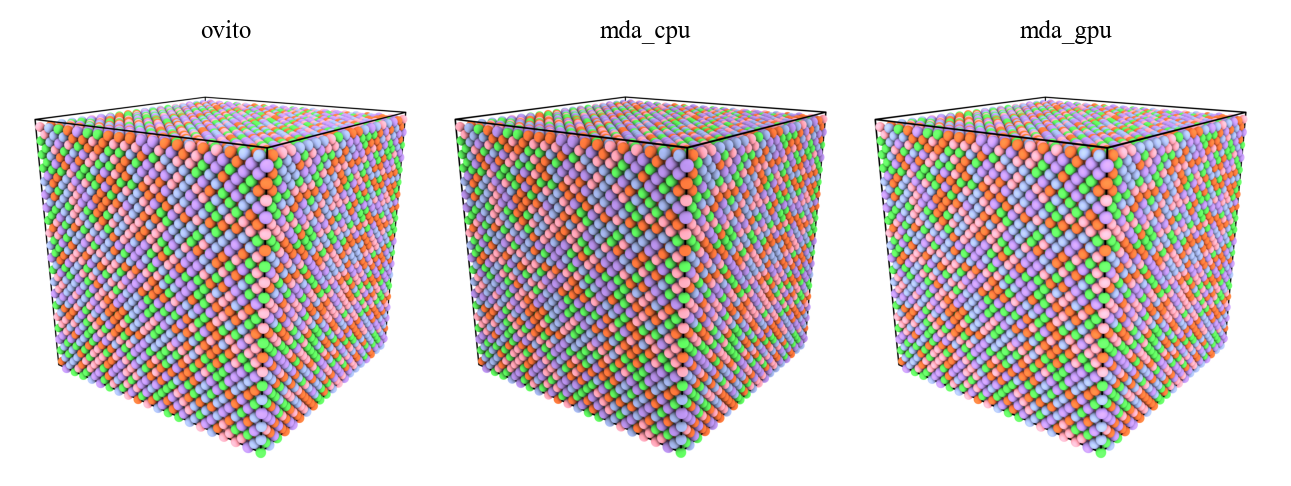

In [16]:
fig, ax = mp.set_figure(ncol=3, figsize=(16, 6), figdpi=200)

for i, name in enumerate(['ovito.png', 'mda_cpu.png', 'mda_gpu.png']):
    ax[i].imshow(load_image(name))
    ax[i].axis("off")
    ax[i].set_title(name.split('.')[0])

Mdapy rendering is much faster!

Text(0, 0.5, 'Time (s)')

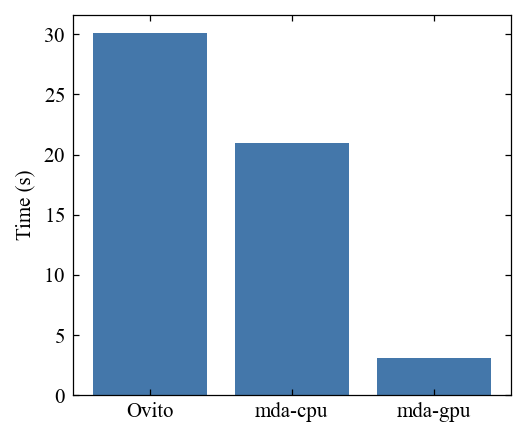

In [17]:
fig, ax = mp.set_figure()
x = range(3)
ax.bar(x, time_list)
ax.set_xticks(x)
ax.set_xticklabels(['Ovito', 'mda-cpu', 'mda-gpu'])
ax.set_ylabel('Time (s)')

In [18]:
import os
from glob import glob
os.remove('model.xyz')
for i in glob('*png'):
    os.remove(i)